In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
mpl.rcParams['figure.dpi'] = 150
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette('cubehelix')

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
data_path = os.listdir(path)[0]
full_path = os.path.join(path, data_path)
print(f"Full Path: {full_path}")

Full Path: C:\Users\ASUS\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


In [3]:
df = pd.read_csv(full_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df[['Time', 'Class']].describe()

,Time,Class
count,284807.000000,284807.000000
mean,94813.859575,0.001727
std,47488.145955,0.041527
min,0.000000,0.000000
25%,54201.500000,0.000000
50%,84692.000000,0.000000
75%,139320.500000,0.000000
max,172792.000000,1.000000


In [8]:
class_value_counts = df['Class'].value_counts()
print('Class Value Counts', class_value_counts)

Class Value Counts Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
print('Duplicated Rows:' , df.duplicated().sum())

Duplicated Rows: 1081


In [10]:
df.drop_duplicates(inplace=True)

class_value_counts = df['Class'].value_counts()
print('Class Values Count', class_value_counts)

Class Values Count Class
0    283253
1       473
Name: count, dtype: int64


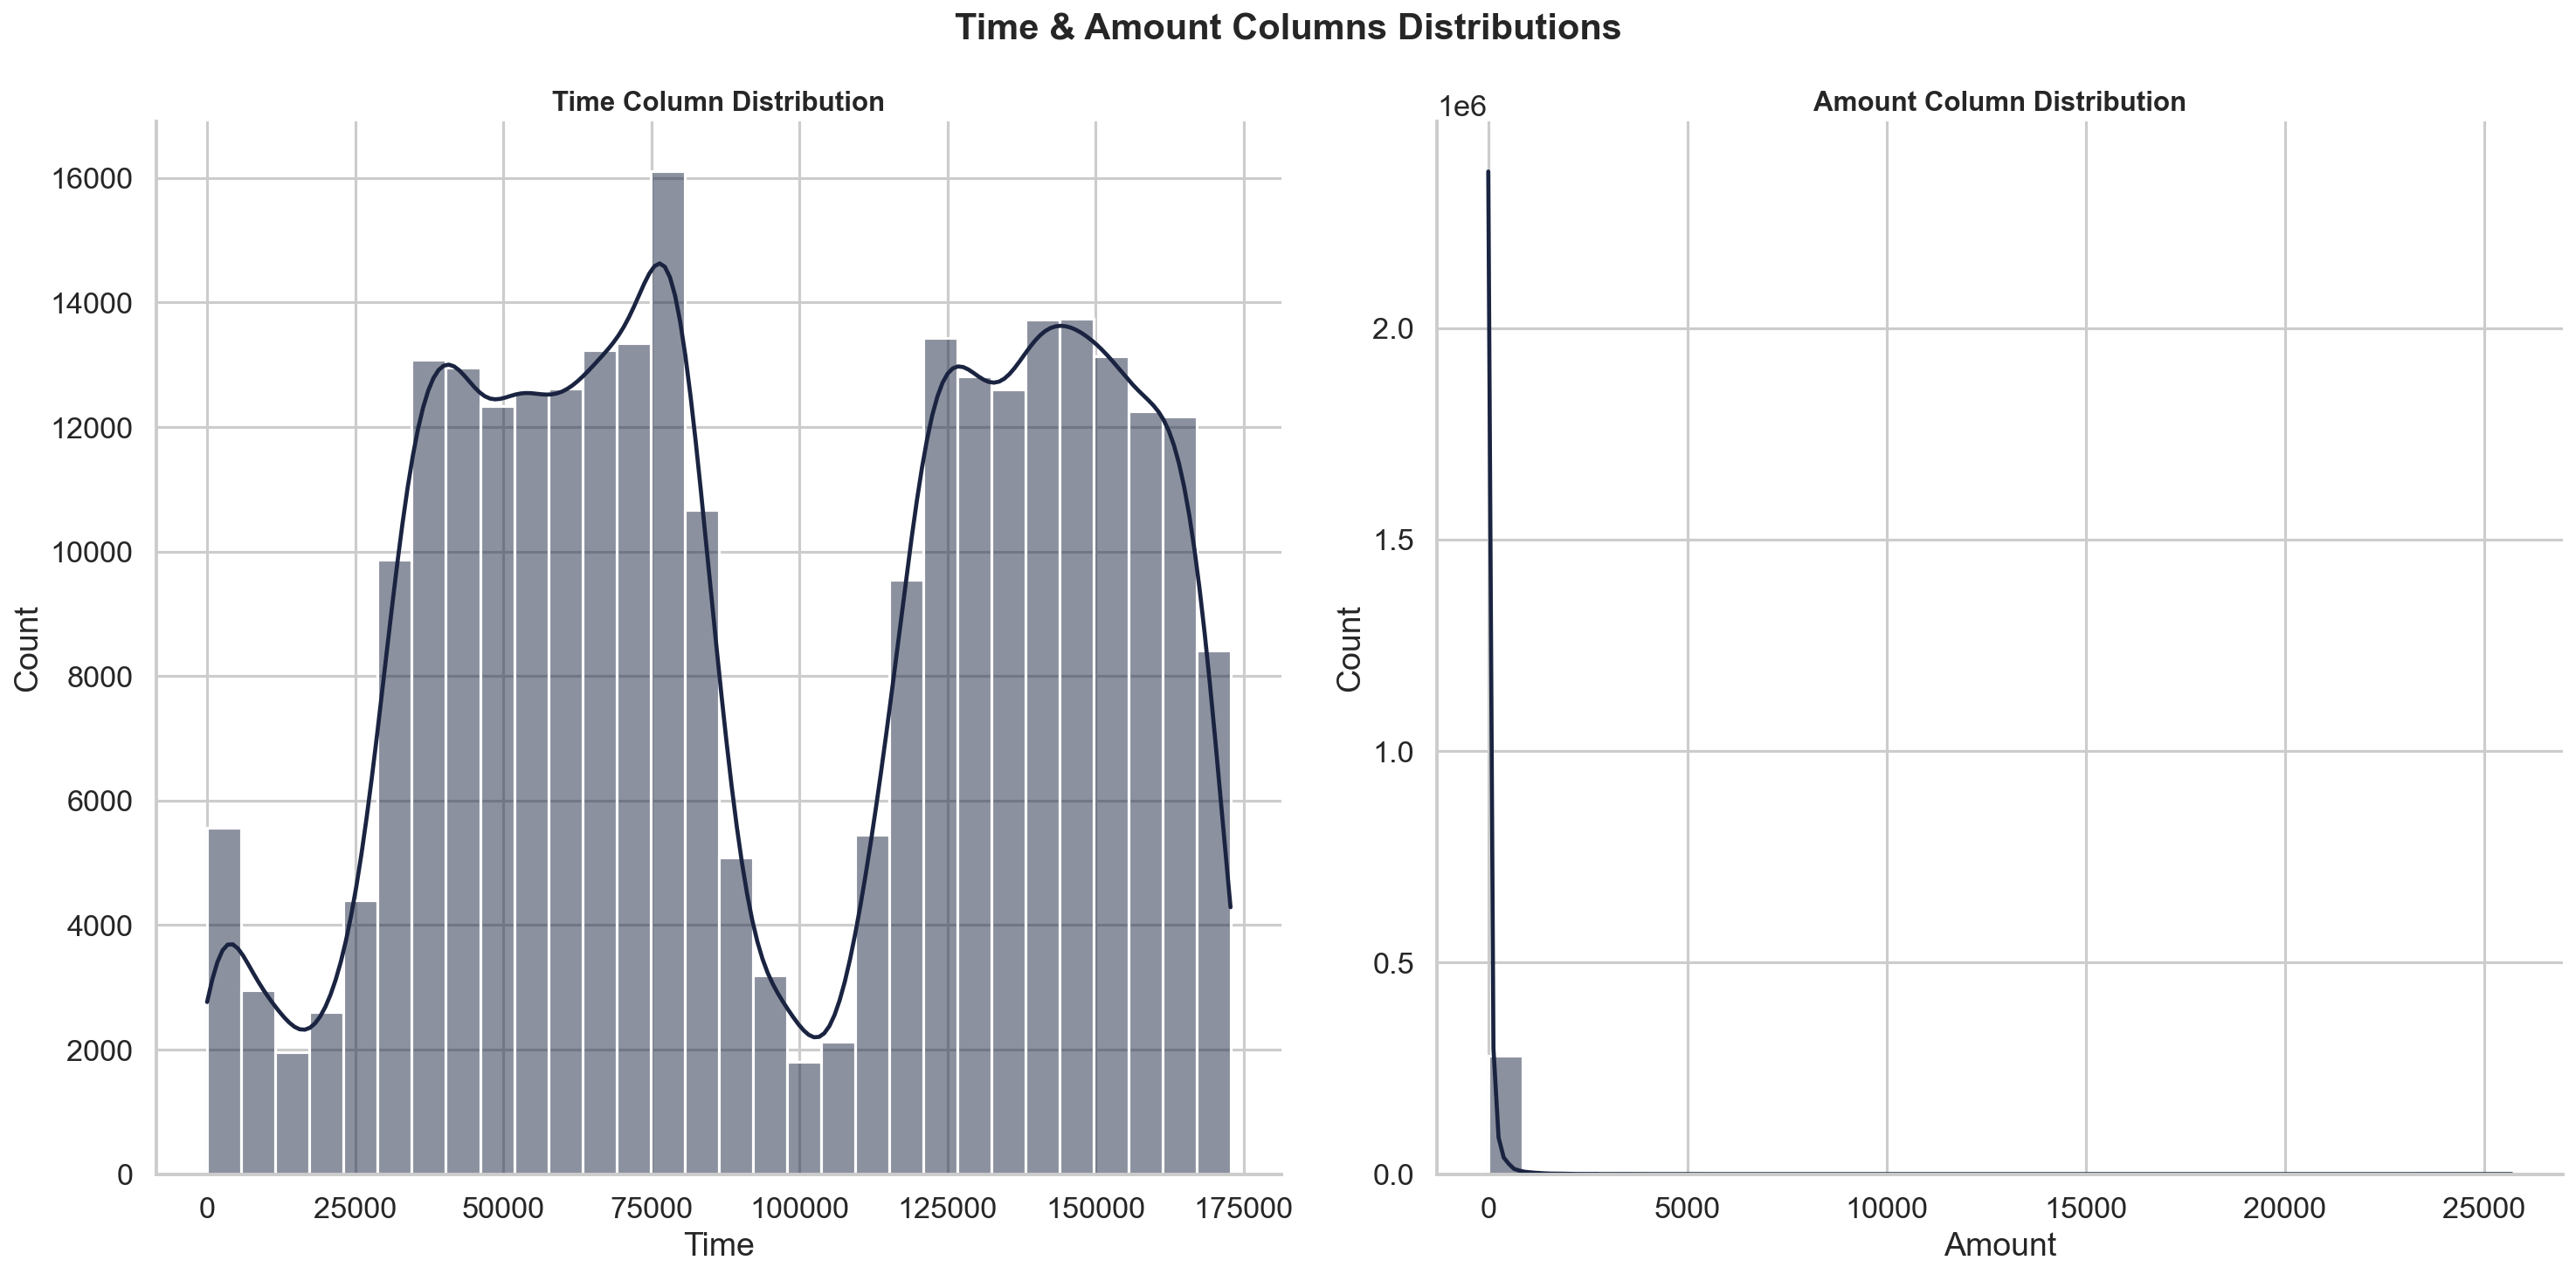

In [11]:
columns = ['Time', 'Amount']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
axes = axes.ravel()

for ax, col in zip(axes, columns):
    sns.histplot(data=df, x=col, ax=ax, bins=30, kde=True)
    ax.set_title(f"{col} Column Distribution", fontsize=15, fontweight="bold")
    
fig.suptitle("Time & Amount Columns Distributions", fontsize=20, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

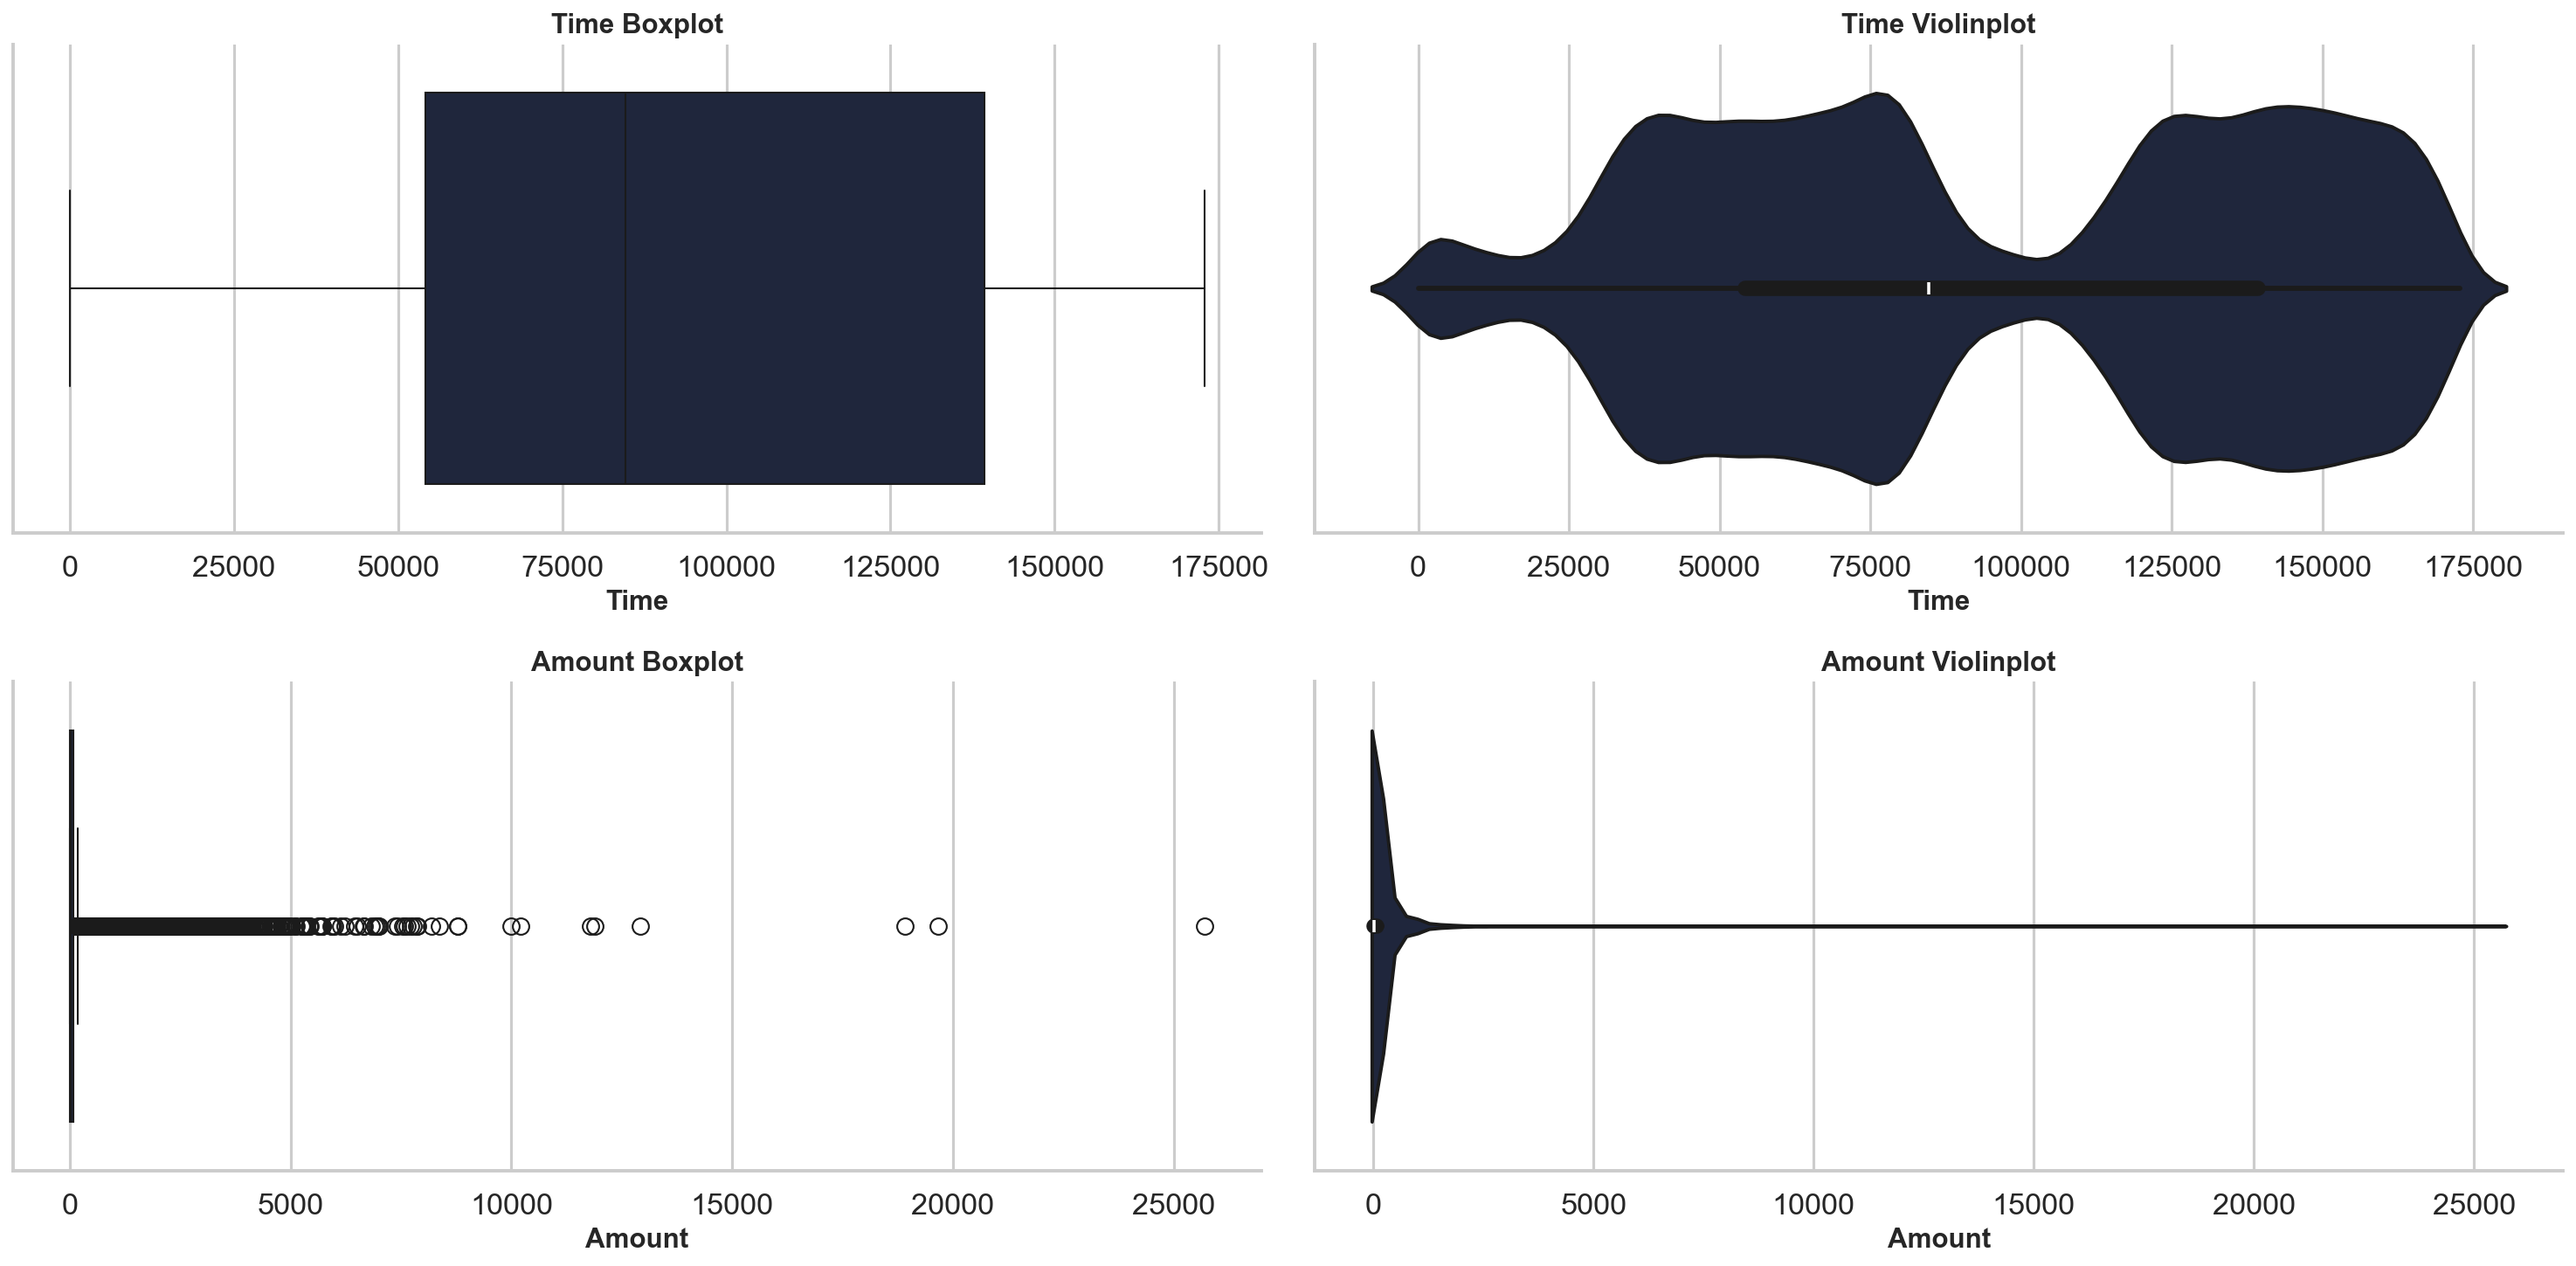

In [12]:
columns = ['Time', 'Amount']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

for i, col in enumerate(columns):
    sns.boxplot(x=col, data=df, ax=axes[i, 0])
    axes[i, 0].set_xlabel(col, fontsize=15, fontweight="bold")
    axes[i, 0].set_title(f'{col} Boxplot', fontsize=15, fontweight="bold")
    
    sns.violinplot(x=col, data=df, ax=axes[i, 1])
    axes[i, 1].set_xlabel(col, fontsize=15, fontweight="bold")
    axes[i, 1].set_title(f'{col} Violinplot', fontsize=15, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

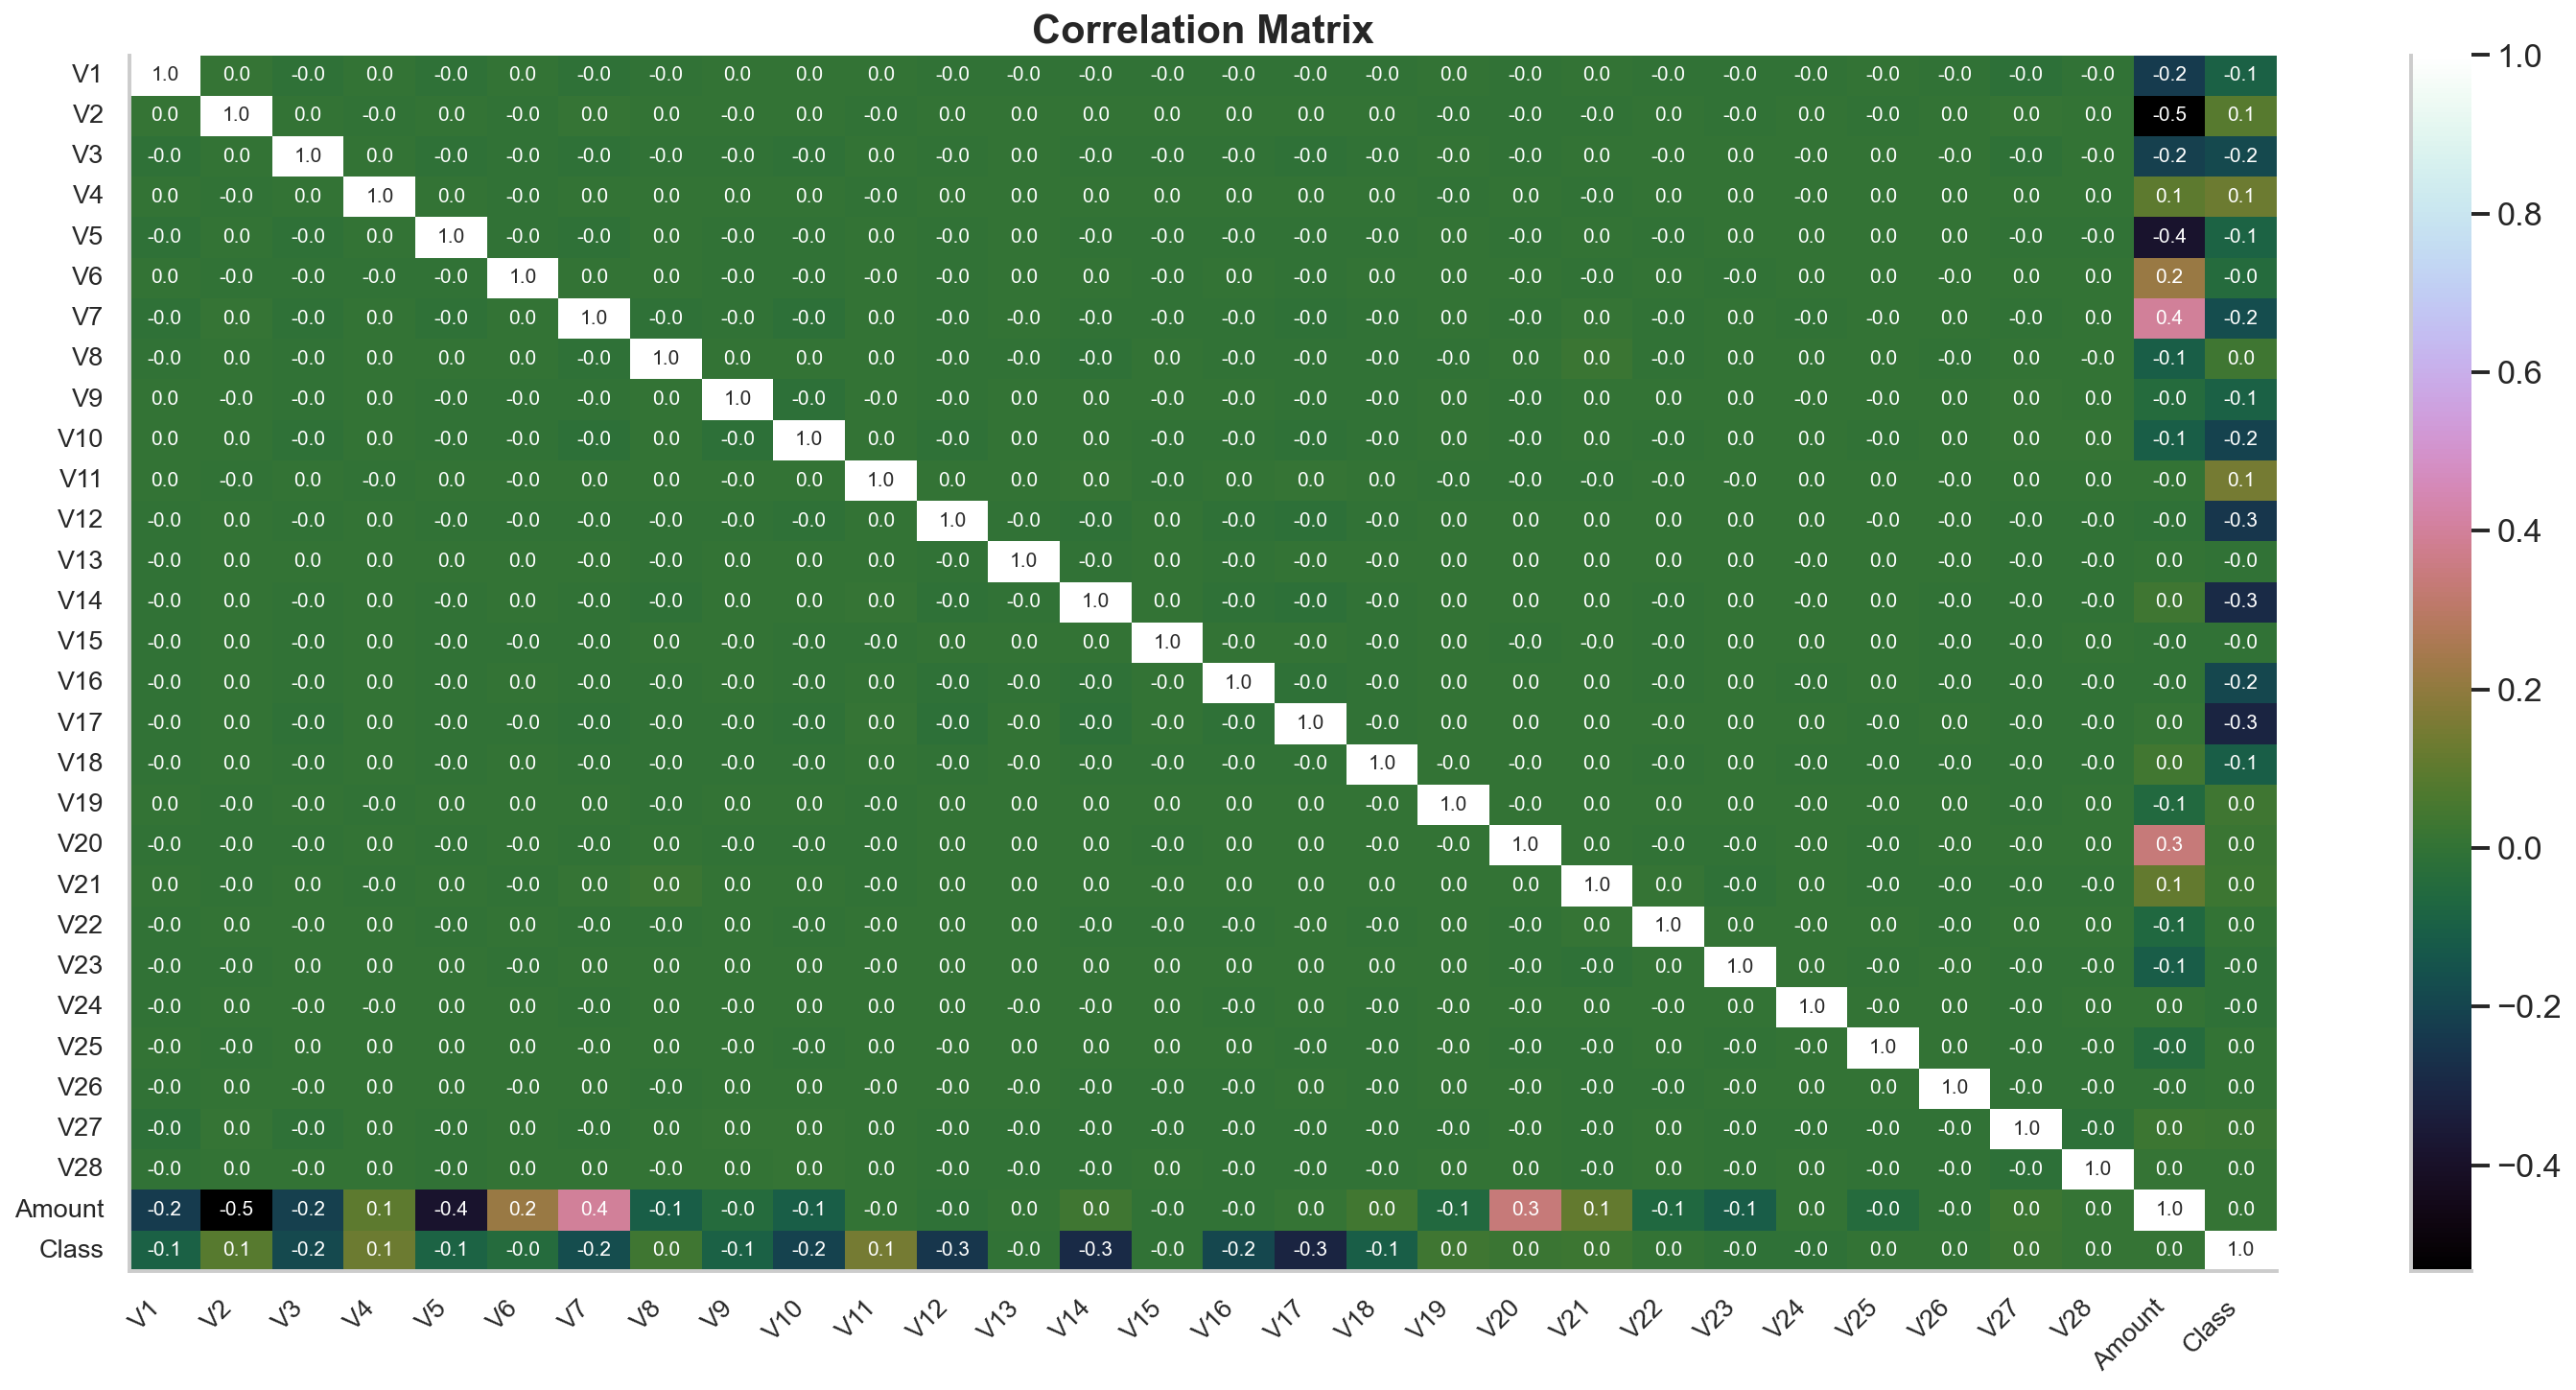

In [13]:
columns = df.drop(columns=['Time']).columns

correlation = df[columns].corr()

plt.figure(figsize=(20, 10))
sns.heatmap(correlation, annot=True, fmt='.1f', annot_kws={'fontsize': 10}, cmap="cubehelix")

sns.despine()
plt.title("Correlation Matrix", fontsize=20, fontweight="bold")
plt.xticks(fontsize=13, rotation=45, ha='right')
plt.yticks(fontsize=13, rotation=0)
plt.tight_layout()
plt.show()

In [14]:
X = df.drop(columns=['Time', 'Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_oversampled)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(226980, 29) (56746, 29)


In [15]:
lr = LogisticRegression(
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

param_dist = {
    'C': stats.loguniform(1e-3, 10),
    'fit_intercept': [True, False],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_cv = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
)

search_cv.fit(X_train_scaled, y_train_oversampled)

best_params = search_cv.best_params_

print('Best parameters:', best_params)
print('Best score:', search_cv.best_score_)

Best parameters: {'C': 0.24810409748678125, 'fit_intercept': True}
Best score: 0.9627458991564058


In [ ]:
def create_confusion_matrix(y_true, y_predictions, ax, annot_size=15, ticks_size=15, title_size=25, labels_size=20):
    cm = confusion_matrix(y_true, y_predictions)
    
    ticks_label = ['Not Fraud', 'Fraud']
    group_names = ['TN', 'FP', 'FN', 'TP']
    cm_values = [value for value in cm.flatten()]
    cm_labels = [f'{label}\n{val}' for val, label in zip(cm_values, group_names)]
    cm_labels = np.array(cm_labels).reshape([2, 2])
    
    sns.heatmap(cm, xticklabels=ticks_label, yticklabels=ticks_label,
            ax=ax, annot=cm_labels, fmt='', annot_kws={'size': annot_size})
    
    ax.set_title('Confusion Matrix', fontsize=title_size, fontweight="bold")
    ax.tick_params(axis='both', labelsize=ticks_size)
    ax.set_xlabel('Predicted', fontsize=labels_size)
    ax.set_ylabel('True', fontsize=labels_size)
    
    
def create_pr_curve(y_true, y_probabilities, ax, ticks_size=15, title_size=20, labels_size=20, legend_size=15):
    precision, recall, thresholds = precision_recall_curve(y_true, y_probabilities)
    
    sns.lineplot(x=thresholds, y=recall[:-1], ax=ax, label='Recall')
    sns.lineplot(x=thresholds, y=precision[:-1], ax=ax, label='Precision')
    
    ax.set_title('Precision-Recall Curve', fontsize=title_size, fontweight="bold")
    ax.tick_params(axis='both', labelsize=ticks_size)
    ax.set_xlabel('Threshold', fontsize=labels_size)
    ax.set_ylabel('Precision-Recall', fontsize=labels_size)
    ax.legend(loc='lower right', frameon=False, fontsize=legend_size)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.07      0.87      0.14        95

    accuracy                           0.98     56746
   macro avg       0.54      0.93      0.56     56746
weighted avg       1.00      0.98      0.99     56746



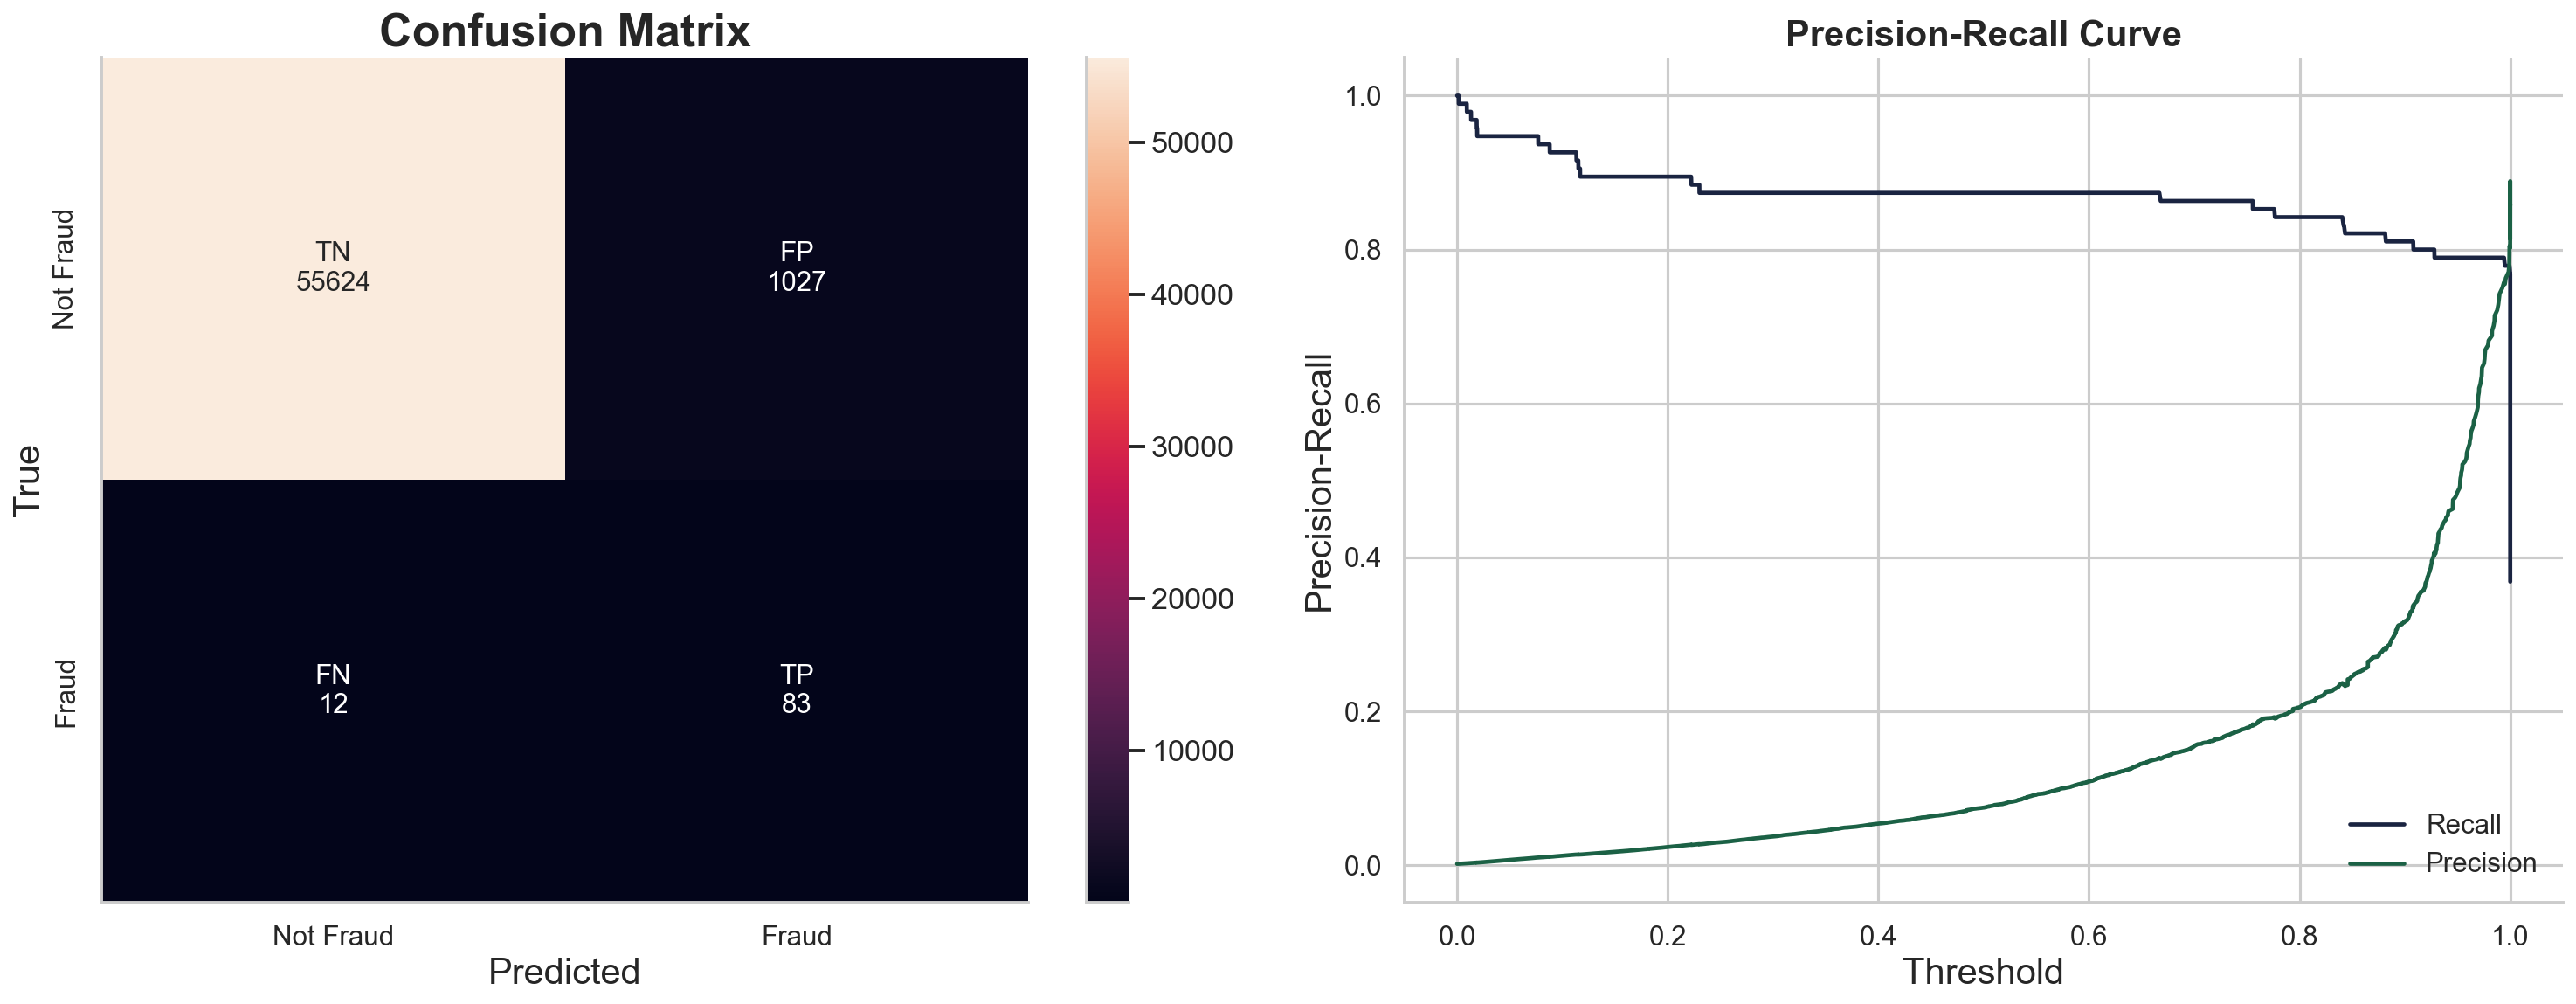

In [45]:
best_estimator = search_cv.best_estimator_
y_pred = best_estimator.predict(X_test_scaled)
y_proba = best_estimator.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
create_confusion_matrix(y_test, y_pred, ax=axes[0])
create_pr_curve(y_test, y_proba, ax=axes[1])

print(classification_report(y_test, y_pred))

sns.despine()
plt.tight_layout()
plt.show()

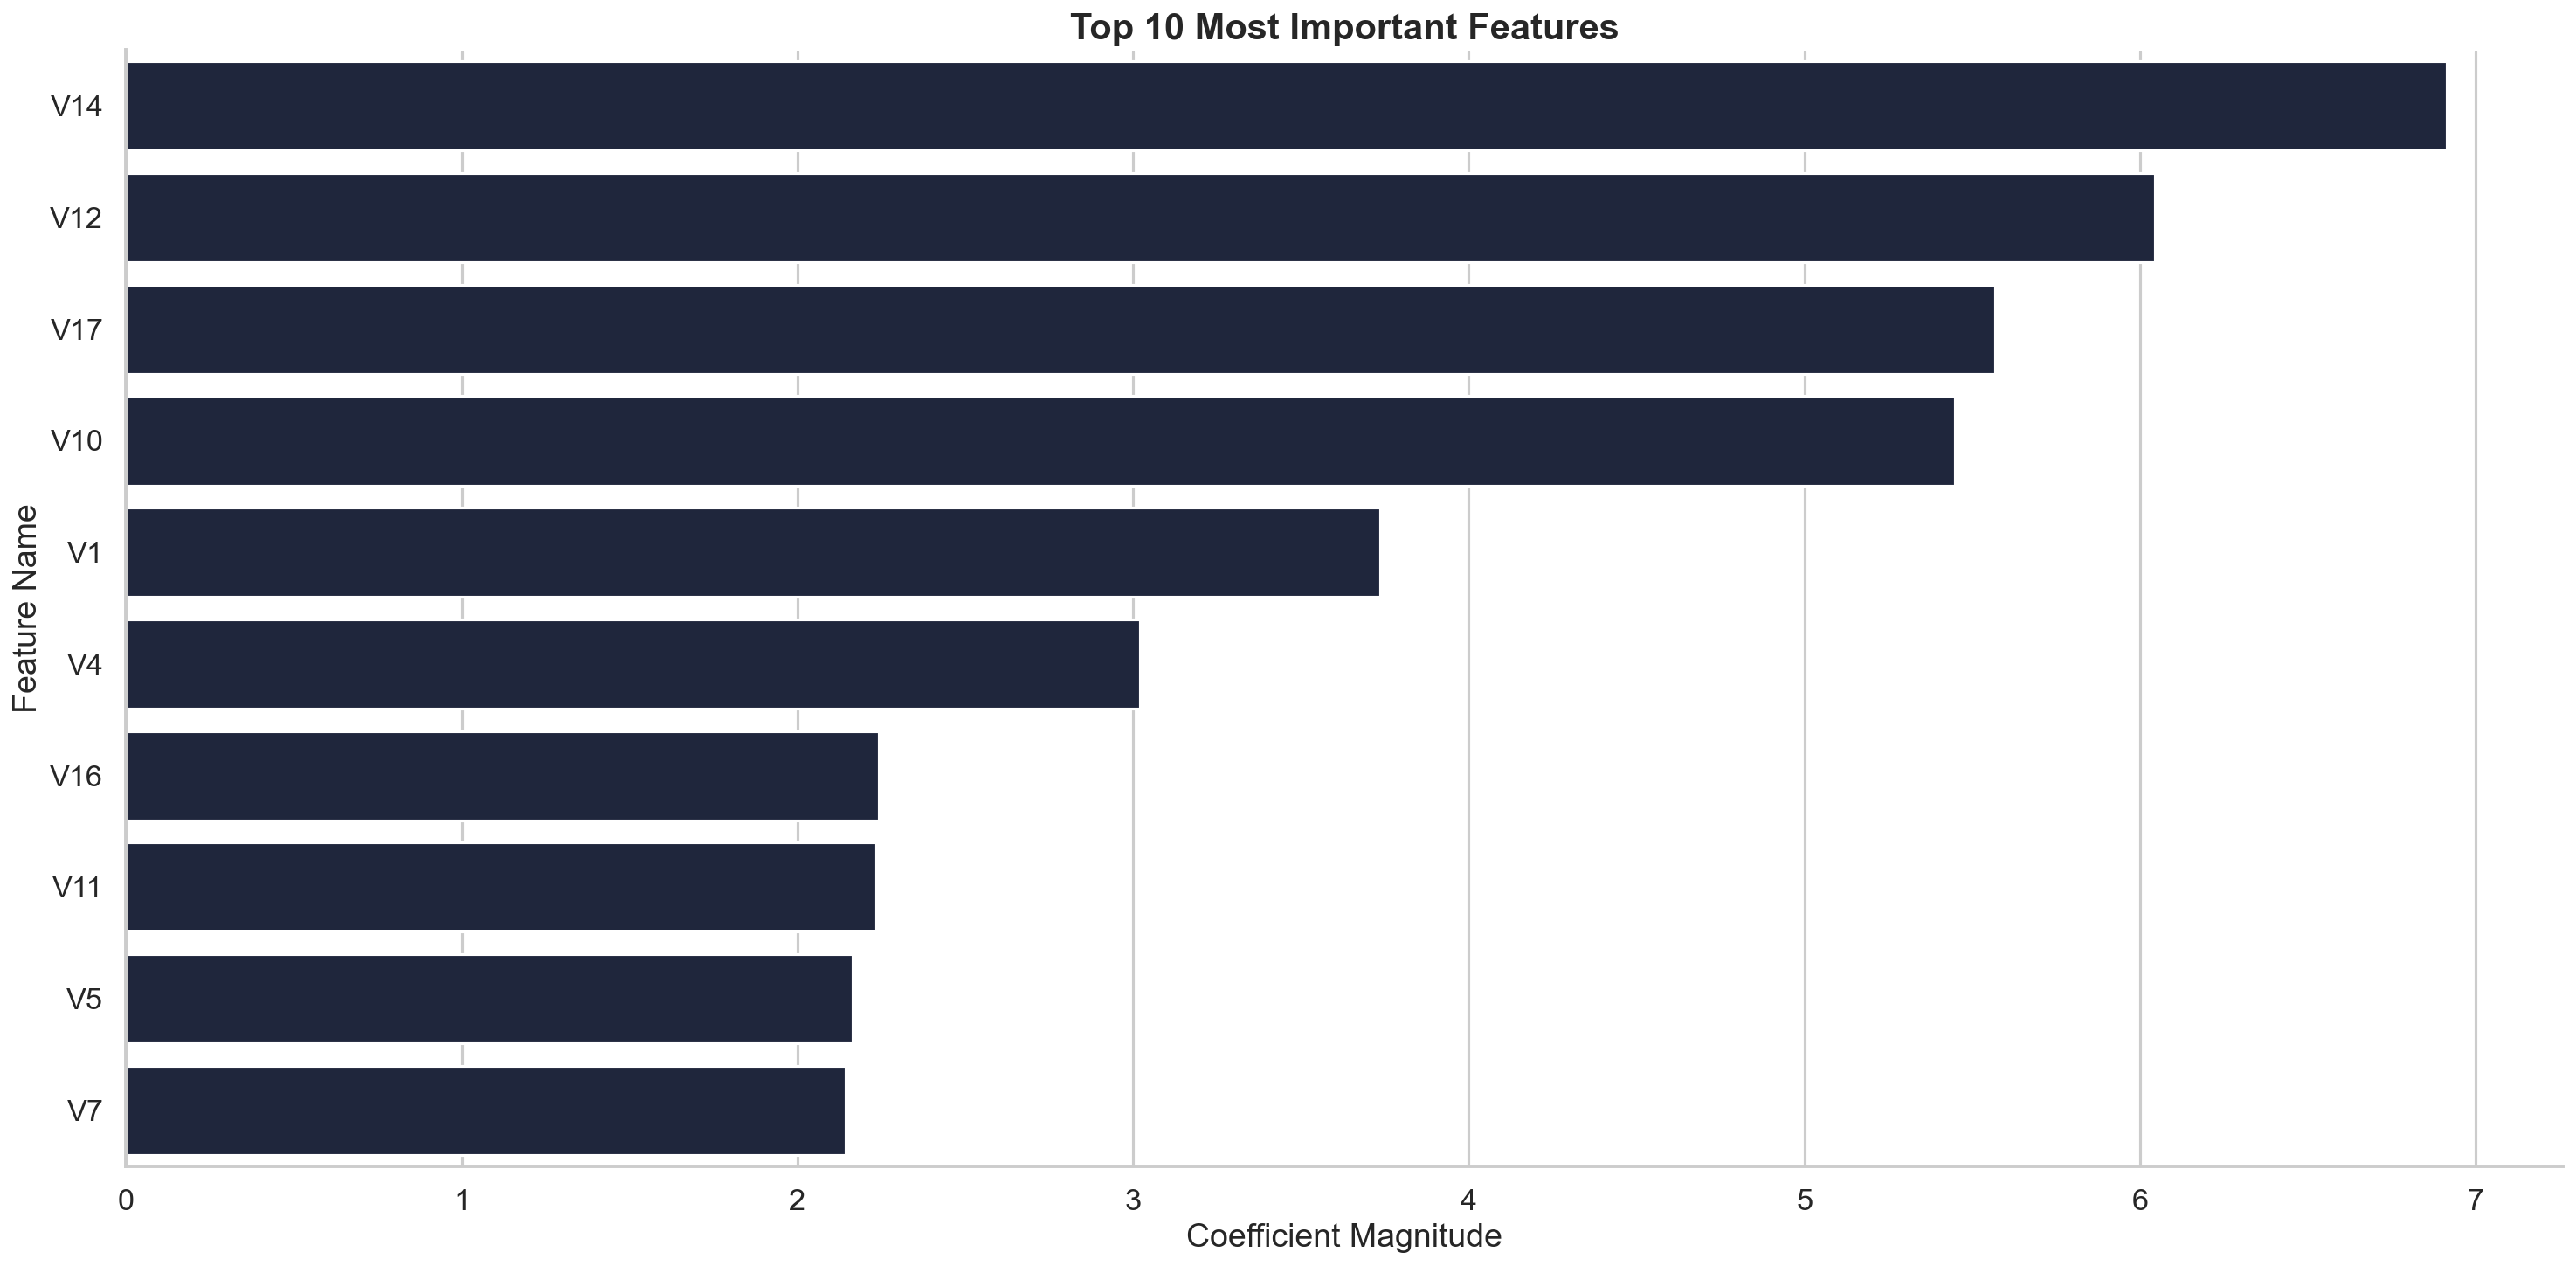

In [46]:
k = 10

coef = best_estimator.coef_.ravel()

features_importance = pd.Series(np.abs(coef)).sort_values(ascending=False)
top_k_best_features = features_importance.head(k)
selected_features = X_train.columns[top_k_best_features.index]

plt.figure(figsize=(20, 10))
sns.barplot(x=top_k_best_features, y=selected_features)
plt.title('Top 10 Most Important Features', fontsize=20, fontweight="bold")
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature Name')
sns.despine()
plt.tight_layout()
plt.show()

In [47]:
lr.set_params(**best_params)

X_train_scaled_new = X_train_scaled[:, top_k_best_features.index]
X_test_scaled_new = X_test_scaled[:, top_k_best_features.index]

lr.fit(X_train_scaled_new, y_train_oversampled)

LogisticRegression(C=0.24810409748678125, class_weight='balanced',
                   max_iter=1000, penalty='l1', random_state=42, solver='saga')

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.08      0.86      0.14        95

    accuracy                           0.98     56746
   macro avg       0.54      0.92      0.57     56746
weighted avg       1.00      0.98      0.99     56746



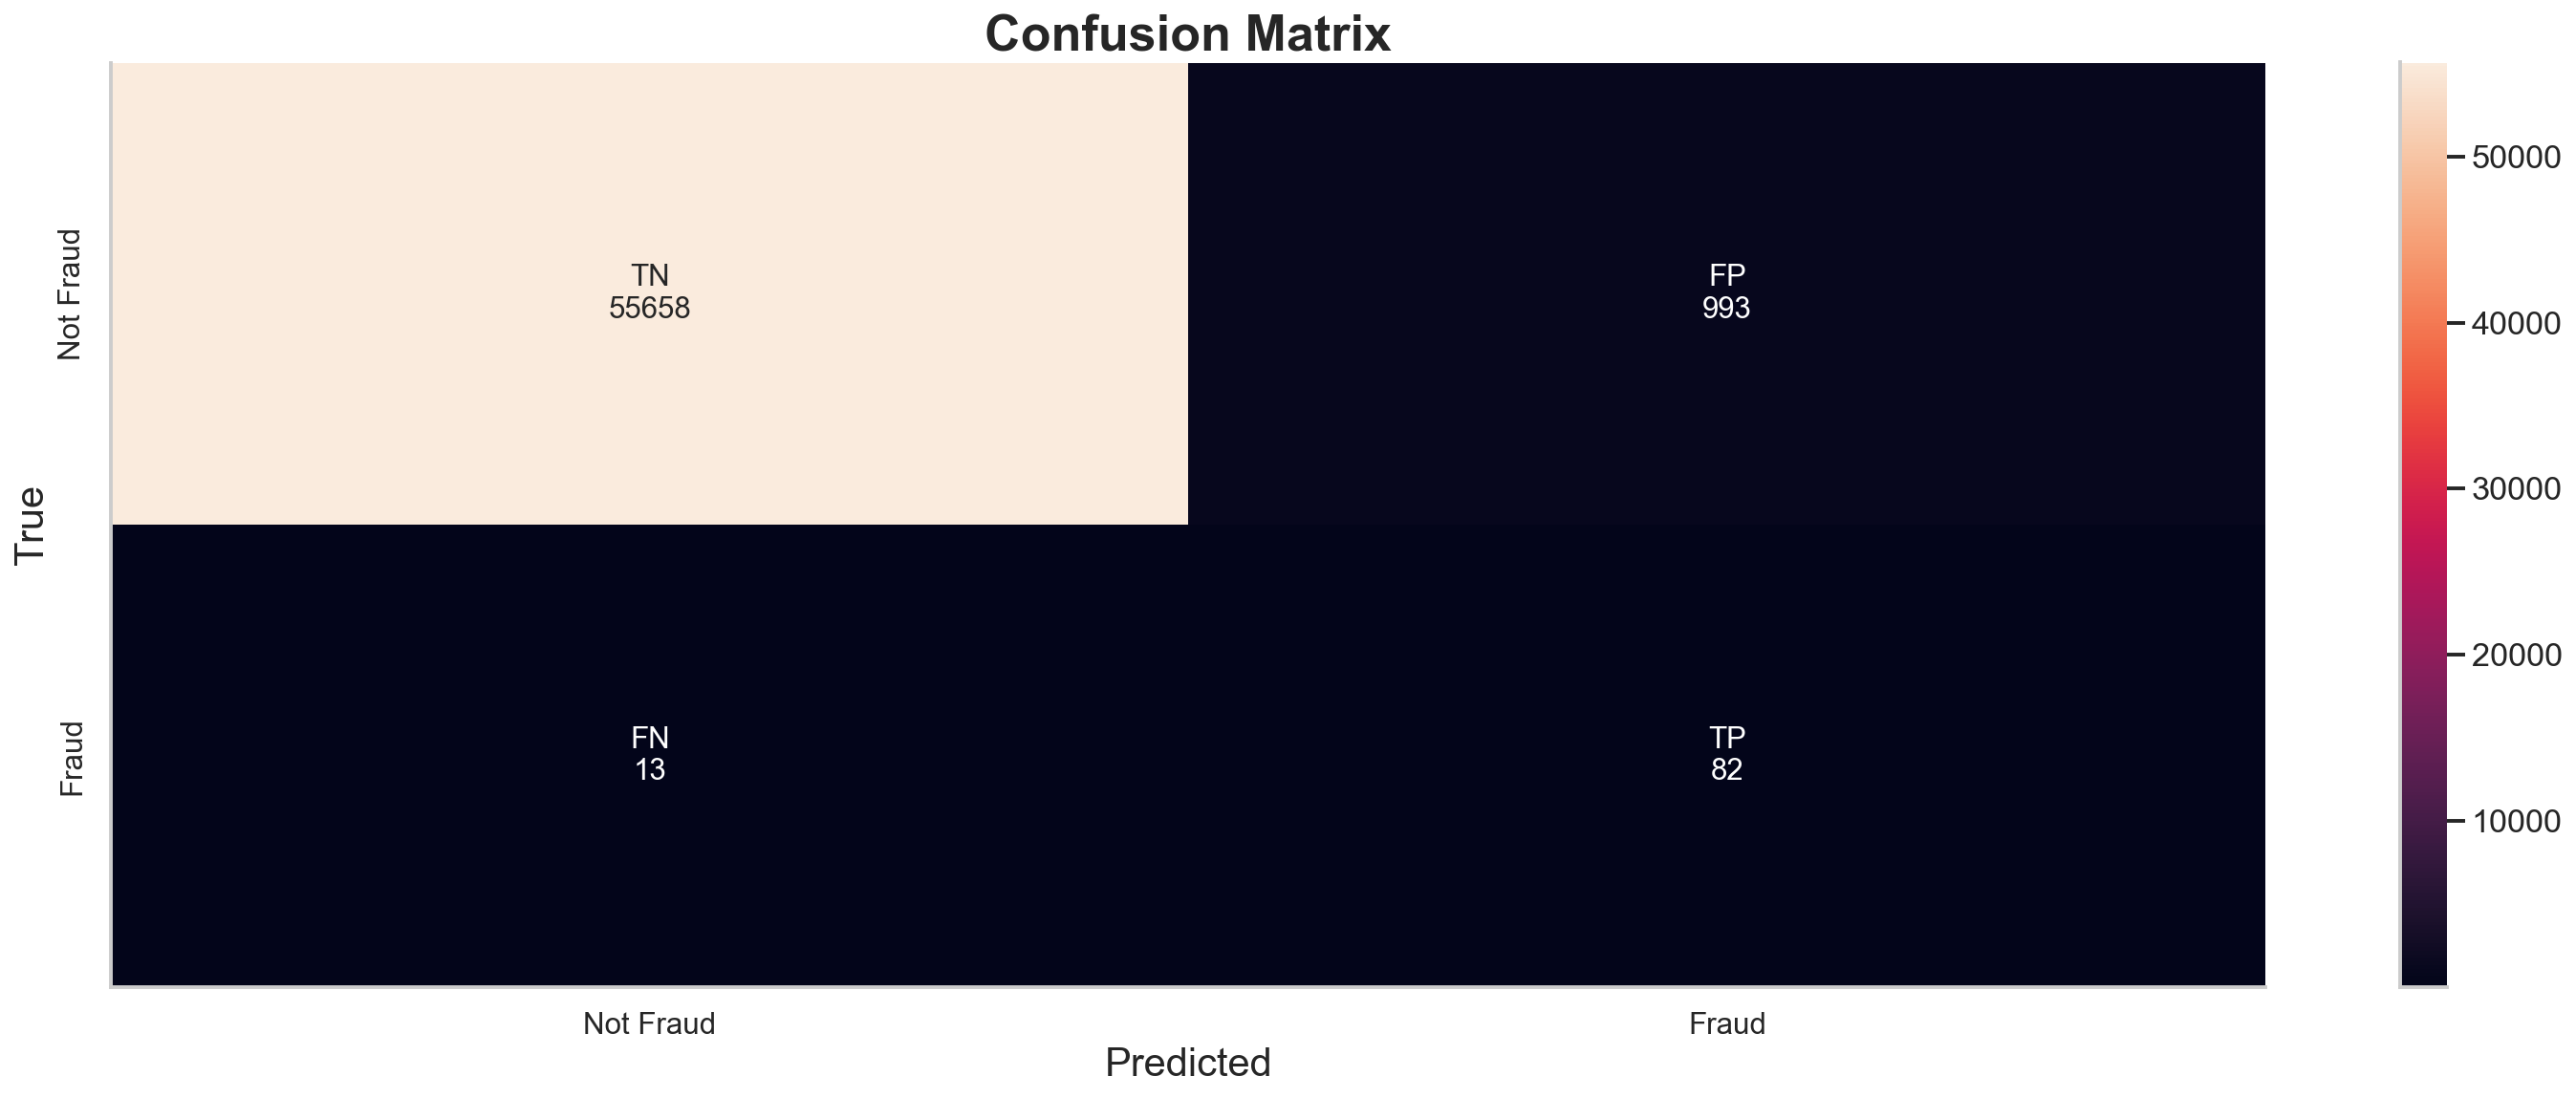

In [48]:
y_pred = lr.predict(X_test_scaled_new)
y_proba = lr.predict_proba(X_test_scaled_new)[:, 1]

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 8))
create_confusion_matrix(y_test, y_pred, ax=axes)

print(classification_report(y_test, y_pred))

sns.despine()
plt.tight_layout()
plt.show()

Best threshold: 0.98989898989899
Best fraud-class F1: 0.7614213197969543
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.74      0.79      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



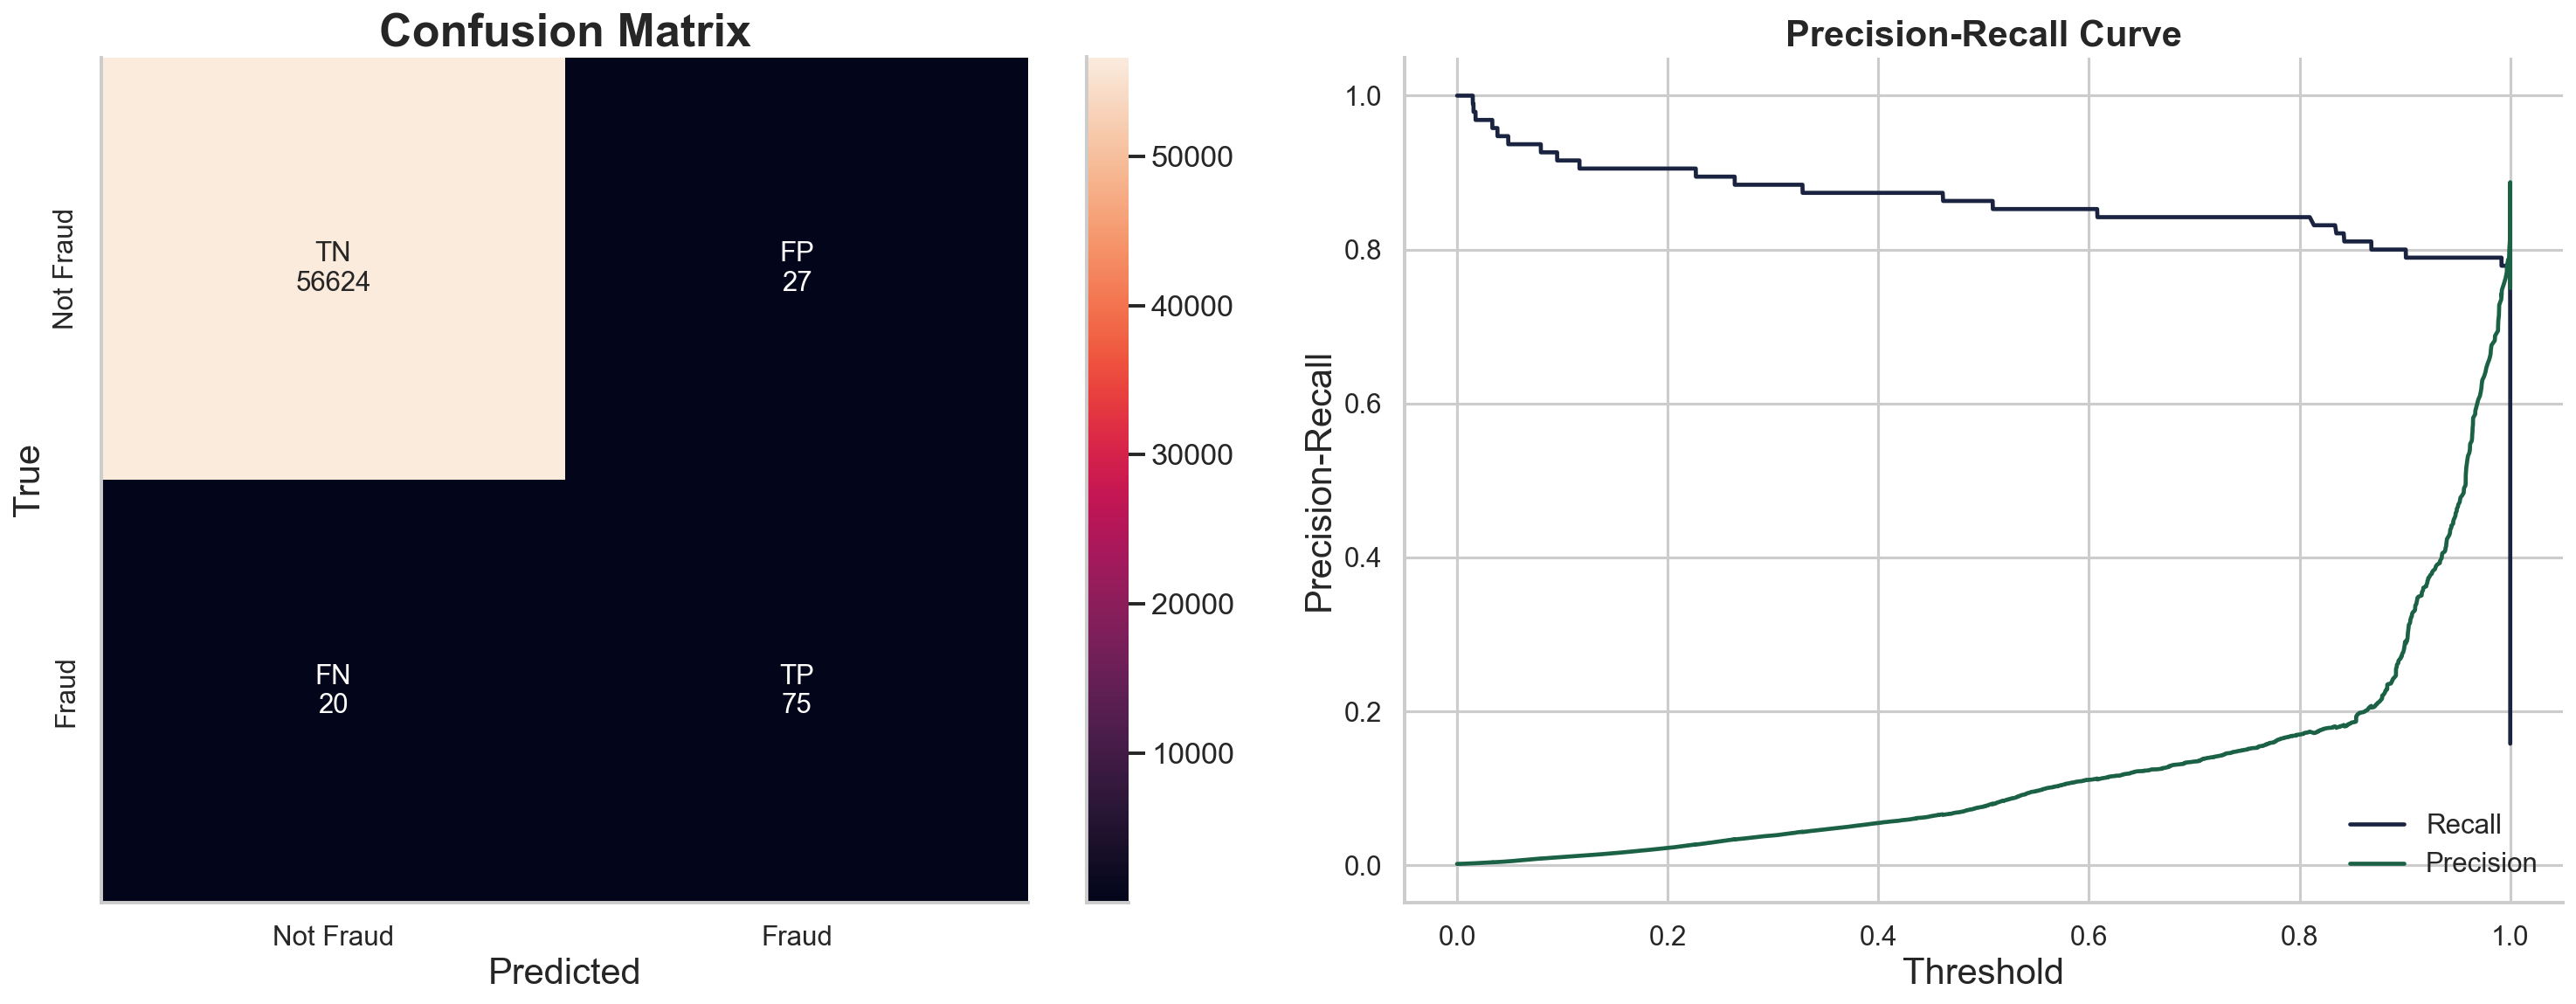

In [49]:
thresholds = np.linspace(0, 1, 100)

best_score = 0
best_threshold = None
best_pred = None

for threshold in thresholds:
    y_pred_tmp = (y_proba >= threshold).astype(int)
    f1_pos = f1_score(y_test, y_pred_tmp, average='binary', pos_label=1)

    if f1_pos > best_score:
        best_score = f1_pos
        best_threshold = threshold
        best_pred = y_pred_tmp

print("Best threshold:", best_threshold)
print("Best fraud-class F1:", best_score)
print(classification_report(y_test, best_pred))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
create_confusion_matrix(y_test, best_pred, ax=axes[0])
create_pr_curve(y_test, y_proba, ax=axes[1])

sns.despine()
plt.tight_layout()
plt.show()